# Data Preprocessing for OULAD Dropout Prediction

This notebook preprocesses the OULAD dataset for dropout prediction by:
1. Loading and merging relevant data files
2. Handling missing values
3. Encoding categorical variables
4. Engineering features (VLE engagement, assessment performance, registration timing)
5. Preparing the final dataset for modeling

## Target Variable
**Dropout**: Binary classification (1 = Withdrawn, 0 = Not Withdrawn)

Based on `final_result` = "Withdrawn" in `studentInfo.csv`


## 1. Setup and Imports


In [1]:
# Install required packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Data Loading


In [3]:
# Find dataset path
# Try multiple possible paths relative to notebook location
possible_paths = [
    '../../datasets/open-university-learning-analytics-dataset/',       # From final_code/preprocessing/
    '../../../datasets/open-university-learning-analytics-dataset/',    # From final_code/
    'datasets/open-university-learning-analytics-dataset/',             # From project root
    '../../../../datasets/open-university-learning-analytics-dataset/',  # From pretests/charaka/analysis/dropout-prediction/
    '../datasets/open-university-learning-analytics-dataset/'           # From final_code/
]

dataset_dir = None
for path in possible_paths:
    if os.path.exists(path):
        dataset_dir = path
        break

if dataset_dir is None:
    raise FileNotFoundError(f"Could not find dataset directory. Tried: {possible_paths}")

print(f"Dataset directory: {os.path.abspath(dataset_dir)}")


Dataset directory: /Users/charaka/Desktop/Projects/uom-student-performance-analytics/datasets/open-university-learning-analytics-dataset


In [4]:
# Load core files
print("Loading data files...")

# Main student information (contains target variable)
student_info = pd.read_csv(os.path.join(dataset_dir, 'studentInfo.csv'))
print(f"✓ studentInfo.csv: {student_info.shape}")

# Registration information
student_reg = pd.read_csv(os.path.join(dataset_dir, 'studentRegistration.csv'))
print(f"✓ studentRegistration.csv: {student_reg.shape}")

# Assessment scores
student_assess = pd.read_csv(os.path.join(dataset_dir, 'studentAssessment.csv'))
print(f"✓ studentAssessment.csv: {student_assess.shape}")

# Assessment metadata
assessments = pd.read_csv(os.path.join(dataset_dir, 'assessments.csv'))
print(f"✓ assessments.csv: {assessments.shape}")

# Course information
courses = pd.read_csv(os.path.join(dataset_dir, 'courses.csv'))
print(f"✓ courses.csv: {courses.shape}")

# VLE material information
vle = pd.read_csv(os.path.join(dataset_dir, 'vle.csv'))
print(f"✓ vle.csv: {vle.shape}")


Loading data files...
✓ studentInfo.csv: (32593, 12)
✓ studentRegistration.csv: (32593, 5)
✓ studentAssessment.csv: (173912, 5)
✓ assessments.csv: (206, 6)
✓ courses.csv: (22, 3)
✓ vle.csv: (6364, 6)


In [5]:
# Load VLE interaction data (split into multiple files)
vle_dir = os.path.join(dataset_dir, 'studentVle_split')
if os.path.exists(vle_dir):
    vle_files = sorted([f for f in os.listdir(vle_dir) if f.endswith('.csv')])
    print(f"\nLoading VLE interaction files ({len(vle_files)} files)...")
    
    # Load first file to check structure
    student_vle_list = []
    for i, vle_file in enumerate(vle_files, 1):
        df_part = pd.read_csv(os.path.join(vle_dir, vle_file))
        student_vle_list.append(df_part)
        print(f"  ✓ {vle_file}: {df_part.shape}")
    
    student_vle = pd.concat(student_vle_list, ignore_index=True)
    print(f"\n✓ Total VLE interactions: {student_vle.shape}")
else:
    print("\n⚠ VLE split directory not found. Skipping VLE interaction features.")
    student_vle = None



Loading VLE interaction files (6 files)...
  ✓ studentVle_part1.csv: (2000000, 6)
  ✓ studentVle_part2.csv: (2000000, 6)
  ✓ studentVle_part3.csv: (2000000, 6)
  ✓ studentVle_part4.csv: (2000000, 6)
  ✓ studentVle_part5.csv: (2000000, 6)
  ✓ studentVle_part6.csv: (655280, 6)

✓ Total VLE interactions: (10655280, 6)


## 3. Initial Data Inspection


In [6]:
# Inspect studentInfo (main dataset)
print("=" * 60)
print("STUDENT INFO DATASET")
print("=" * 60)
print(f"Shape: {student_info.shape}")
print(f"\nColumns: {list(student_info.columns)}")
print(f"\nFirst few rows:")
student_info.head()


STUDENT INFO DATASET
Shape: (32593, 12)

Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

First few rows:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [7]:
# Check target variable distribution
print("=" * 60)
print("TARGET VARIABLE: final_result")
print("=" * 60)
result_counts = student_info['final_result'].value_counts()
result_pct = student_info['final_result'].value_counts(normalize=True) * 100

result_df = pd.DataFrame({
    'Count': result_counts,
    'Percentage': result_pct
})
print(result_df)

# Create dropout target
student_info['is_dropout'] = (student_info['final_result'] == 'Withdrawn').astype(int)
print(f"\nDropout rate: {student_info['is_dropout'].mean() * 100:.2f}%")
print(f"Non-dropout rate: {(1 - student_info['is_dropout'].mean()) * 100:.2f}%")


TARGET VARIABLE: final_result
              Count  Percentage
final_result                   
Pass          12361   37.925321
Withdrawn     10156   31.160065
Fail           7052   21.636548
Distinction    3024    9.278066

Dropout rate: 31.16%
Non-dropout rate: 68.84%


In [8]:
# Check for missing values
print("=" * 60)
print("MISSING VALUES IN STUDENT INFO")
print("=" * 60)
missing = student_info.isnull().sum()
missing_pct = (missing / len(student_info)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found.")


MISSING VALUES IN STUDENT INFO
No missing values found.


## 4. Feature Engineering


In [9]:
# Start with student_info as base
df = student_info.copy()
print(f"Starting with {df.shape[0]} students")


Starting with 32593 students


### 4.1 Merge Registration Data


In [10]:
# Merge registration data
df = df.merge(
    student_reg,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

print(f"After merging registration: {df.shape}")

# Convert date columns to numeric (handle any string values or missing data)
# This is necessary because CSV might read them as strings if there are missing values
df['date_registration'] = pd.to_numeric(df['date_registration'], errors='coerce')
df['date_unregistration'] = pd.to_numeric(df['date_unregistration'], errors='coerce')

# Create registration timing features
# Early registration (negative days = registered before course start)
df['registered_early'] = (df['date_registration'] < 0).astype(int)
df['registered_late'] = (df['date_registration'] > 0).astype(int)

# Days before/after course start (handle NaN values)
df['days_before_start'] = df['date_registration'].apply(
    lambda x: abs(x) if pd.notna(x) and x < 0 else 0
)
df['days_after_start'] = df['date_registration'].apply(
    lambda x: x if pd.notna(x) and x > 0 else 0
)

# Unregistration indicator (dropout indicator)
df['has_unregistration'] = df['date_unregistration'].notna().astype(int)

# If unregistered, days until unregistration
df['days_until_unregistration'] = df['date_unregistration'].fillna(0)

print("✓ Registration features created")


After merging registration: (32593, 15)
✓ Registration features created


### 4.2 Merge Course Information


In [11]:
# Merge course information
df = df.merge(
    courses,
    on=['code_module', 'code_presentation'],
    how='left'
)

print(f"After merging courses: {df.shape}")
print("✓ Course features merged")


After merging courses: (32593, 22)
✓ Course features merged


### 4.3 Aggregate Assessment Performance


In [12]:
# Merge assessment metadata to get weights
student_assess_merged = student_assess.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'weight']],
    on='id_assessment',
    how='left'
)

# Convert all numeric columns to proper types (handle any string values)
# This is necessary because CSV might read them as strings if there are missing values or large numbers
student_assess_merged['score'] = pd.to_numeric(student_assess_merged['score'], errors='coerce')
student_assess_merged['date_submitted'] = pd.to_numeric(student_assess_merged['date_submitted'], errors='coerce')
student_assess_merged['weight'] = pd.to_numeric(student_assess_merged['weight'], errors='coerce')
student_assess_merged['is_banked'] = pd.to_numeric(student_assess_merged['is_banked'], errors='coerce').fillna(0).astype(int)

# Filter out rows where score is NaN before aggregation
student_assess_valid = student_assess_merged[student_assess_merged['score'].notna()].copy()

# Aggregate assessment scores per student
assessment_features = student_assess_valid.groupby(
    ['code_module', 'code_presentation', 'id_student']
).agg({
    'score': ['mean', 'min', 'max', 'count'],
    'date_submitted': ['min', 'max'],
    'is_banked': 'sum'
}).reset_index()

# Flatten column names
assessment_features.columns = [
    'code_module', 'code_presentation', 'id_student',
    'avg_assessment_score', 'min_assessment_score', 'max_assessment_score',
    'num_assessments', 'first_assessment_day', 'last_assessment_day',
    'num_banked_assessments'
]

# Calculate weighted average (if weights available)
# Check that weights sum to non-zero before using np.average
def calculate_weighted_avg(group):
    scores = group['score'].values
    weights = group['weight'].values
    
    # Check if we have valid scores and weights
    if len(scores) == 0 or not np.any(~np.isnan(scores)):
        return np.nan
    
    # Check if weights are available and sum to non-zero
    valid_weights = ~np.isnan(weights)
    if np.any(valid_weights):
        weight_sum = np.nansum(weights[valid_weights])
        if weight_sum > 0:
            # Use weighted average
            valid_mask = ~np.isnan(scores) & valid_weights
            if np.any(valid_mask):
                return np.average(scores[valid_mask], weights=weights[valid_mask])
    
    # Fall back to simple mean
    return np.nanmean(scores)

weighted_scores = student_assess_valid.groupby(
    ['code_module', 'code_presentation', 'id_student']
).apply(calculate_weighted_avg).reset_index(name='weighted_avg_score')

assessment_features = assessment_features.merge(
    weighted_scores,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

# Merge assessment features
df = df.merge(
    assessment_features,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

print(f"After merging assessments: {df.shape}")
print("✓ Assessment features created")


After merging assessments: (32593, 30)
✓ Assessment features created


### 4.4 Aggregate VLE Engagement


In [13]:
if student_vle is not None:
    # Aggregate VLE interactions per student
    vle_features = student_vle.groupby(
        ['code_module', 'code_presentation', 'id_student']
    ).agg({
        'sum_click': ['sum', 'mean', 'max', 'count'],
        'date': ['min', 'max']
    }).reset_index()
    
    # Flatten column names
    vle_features.columns = [
        'code_module', 'code_presentation', 'id_student',
        'total_vle_clicks', 'avg_daily_clicks', 'max_daily_clicks',
        'vle_interaction_days', 'first_vle_day', 'last_vle_day'
    ]
    
    # Calculate engagement metrics
    vle_features['vle_engagement_rate'] = vle_features['total_vle_clicks'] / vle_features['vle_interaction_days'].replace(0, 1)
    
    # Merge VLE features
    df = df.merge(
        vle_features,
        on=['code_module', 'code_presentation', 'id_student'],
        how='left'
    )
    
    print(f"After merging VLE: {df.shape}")
    print("✓ VLE engagement features created")
else:
    print("⚠ Skipping VLE features (data not available)")


After merging VLE: (32593, 37)
✓ VLE engagement features created


### 4.5 Create Additional Features


In [14]:
# Extract presentation year and semester
df['presentation_year'] = df['code_presentation'].str[:4].astype(int)
df['presentation_semester'] = df['code_presentation'].str[4]  # B or J

# Create binary features
df['has_disability'] = (df['disability'] == 'Y').astype(int)

# Previous attempts (already numeric, but ensure it's int)
df['num_of_prev_attempts'] = df['num_of_prev_attempts'].fillna(0).astype(int)

# Studied credits (already numeric)
df['studied_credits'] = df['studied_credits'].fillna(0).astype(int)

print("✓ Additional features created")
print(f"Final dataset shape: {df.shape}")


✓ Additional features created
Final dataset shape: (32593, 40)


## 5. Handle Missing Values


In [15]:
# Check missing values in final dataset
print("=" * 60)
print("MISSING VALUES SUMMARY")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found.")


MISSING VALUES SUMMARY
                        Missing Count  Missing %
date_unregistration             22521  69.097659
num_banked_assessments           6773  20.780536
avg_assessment_score             6773  20.780536
min_assessment_score             6773  20.780536
max_assessment_score             6773  20.780536
num_assessments                  6773  20.780536
first_assessment_day             6773  20.780536
last_assessment_day              6773  20.780536
weighted_avg_score               6773  20.780536
vle_interaction_days             3365  10.324303
last_vle_day                     3365  10.324303
first_vle_day                    3365  10.324303
vle_engagement_rate              3365  10.324303
max_daily_clicks                 3365  10.324303
avg_daily_clicks                 3365  10.324303
total_vle_clicks                 3365  10.324303
date_registration                  45   0.138066


In [16]:
# Handle missing values
print("Handling missing values...")

# For numeric columns, fill with median or 0
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['is_dropout', 'id_student']]

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        # Fill with 0 for counts/sums, median for averages
        if 'avg' in col.lower() or 'mean' in col.lower() or 'rate' in col.lower():
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(0, inplace=True)

# For categorical columns, fill with mode or 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = [col for col in categorical_cols if col not in ['code_module', 'code_presentation']]

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
        df[col].fillna(mode_value, inplace=True)

print("✓ Missing values handled")
print(f"Remaining missing values: {df.isnull().sum().sum()}")


Handling missing values...
✓ Missing values handled
Remaining missing values: 0


## 6. Encode Categorical Variables


In [17]:
# Identify categorical columns to encode
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Exclude identifier columns
categorical_cols = [col for col in categorical_cols if col not in ['code_module', 'code_presentation', 'final_result']]

print(f"Categorical columns to encode: {len(categorical_cols)}")
print(categorical_cols)


Categorical columns to encode: 7
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'presentation_semester']


In [18]:
# Create label encoders for each categorical column
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"✓ Encoded {col}: {len(le.classes_)} unique values")

# Drop original categorical columns (keep encoded versions)
df = df.drop(columns=categorical_cols)

print(f"\n✓ Categorical encoding complete")
print(f"Dataset shape after encoding: {df.shape}")


✓ Encoded gender: 2 unique values
✓ Encoded region: 13 unique values
✓ Encoded highest_education: 5 unique values
✓ Encoded imd_band: 11 unique values
✓ Encoded age_band: 3 unique values
✓ Encoded disability: 2 unique values
✓ Encoded presentation_semester: 2 unique values

✓ Categorical encoding complete
Dataset shape after encoding: (32593, 40)


## 7. Prepare Features and Target


In [19]:
# Separate features and target
# Exclude identifier columns and target
exclude_cols = ['code_module', 'code_presentation', 'id_student', 'final_result', 'is_dropout']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df['is_dropout'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumber of features: {len(feature_cols)}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")


Features shape: (32593, 35)
Target shape: (32593,)

Number of features: 35

Feature columns:
   1. num_of_prev_attempts
   2. studied_credits
   3. date_registration
   4. date_unregistration
   5. registered_early
   6. registered_late
   7. days_before_start
   8. days_after_start
   9. has_unregistration
  10. days_until_unregistration
  11. module_presentation_length
  12. avg_assessment_score
  13. min_assessment_score
  14. max_assessment_score
  15. num_assessments
  16. first_assessment_day
  17. last_assessment_day
  18. num_banked_assessments
  19. weighted_avg_score
  20. total_vle_clicks
  21. avg_daily_clicks
  22. max_daily_clicks
  23. vle_interaction_days
  24. first_vle_day
  25. last_vle_day
  26. vle_engagement_rate
  27. presentation_year
  28. has_disability
  29. gender_encoded
  30. region_encoded
  31. highest_education_encoded
  32. imd_band_encoded
  33. age_band_encoded
  34. disability_encoded
  35. presentation_semester_encoded


TARGET DISTRIBUTION
                 Count  Percentage
Not Dropout (0)  22437   68.839935
Dropout (1)      10156   31.160065


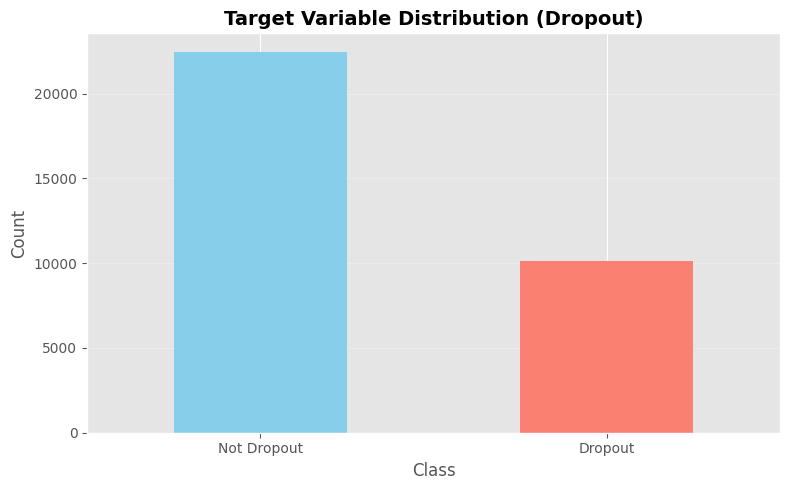

In [20]:
# Check target distribution
print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
target_counts = y.value_counts()
target_pct = y.value_counts(normalize=True) * 100

target_df = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct
})
target_df.index = ['Not Dropout (0)', 'Dropout (1)']
print(target_df)

# Visualize target distribution
plt.figure(figsize=(8, 5))
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Variable Distribution (Dropout)', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Not Dropout', 'Dropout'], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Prepare Data Splits (for internal use)


In [ ]:
# Create data splits for feature scaling (internal use only)
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class distribution
)

# Second split: 80% train, 20% validation (of the 80%)
# This gives us: 64% train, 16% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print("✓ Data splits created for feature scaling")


DATASET SPLITS
Training set:   20,859 samples (64.0%)
Validation set: 5,215 samples (16.0%)
Test set:       6,519 samples (20.0%)

Total:          32,593 samples

TARGET DISTRIBUTION IN EACH SPLIT

Training set:
  Dropout:    6,500 (31.16%)
  Not Dropout: 14,359 (68.84%)

Validation set:
  Dropout:    1,625 (31.16%)
  Not Dropout: 3,590 (68.84%)

Test set:
  Dropout:    2,031 (31.16%)
  Not Dropout: 4,488 (68.84%)


## 9. Summary


In [ ]:
print("=" * 60)
print("DATA PREPARATION SUMMARY")
print("=" * 60)
print(f"\nOriginal dataset: {student_info.shape[0]:,} students")
print(f"Final feature set: {len(feature_cols)} features")
print(f"Final dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(f"  - Dropout rate: {y.mean()*100:.2f}%")
print(f"  - Class imbalance: {'Yes' if abs(y.mean() - 0.5) > 0.1 else 'No'}")
print(f"\n✓ Data preprocessing complete!")


DATA PREPARATION SUMMARY

Original dataset: 32,593 students
Final feature set: 35 features

Dataset splits:
  - Training:   20,859 samples
  - Validation: 5,215 samples
  - Test:       6,519 samples

Target distribution:
  - Dropout rate: 31.16%
  - Class imbalance: Yes

✓ Data is ready for modeling!

Available datasets:
  - X_train, y_train: Training data (original scale)
  - X_val, y_val: Validation data (original scale)
  - X_test, y_test: Test data (original scale)
  - X_train_scaled, X_val_scaled, X_test_scaled: Scaled versions (for models requiring scaling)


In [24]:
## 11. Save Final Prepared Dataset

# Create output directory if it doesn't exist
# Save in final_code/datasets folder relative to the notebook location
output_dir = '../datasets'
os.makedirs(output_dir, exist_ok=True)

# Save the full prepared dataset
output_file = os.path.join(output_dir, 'oulad_dropout_prediction_prepared.csv')
df.to_csv(output_file, index=False)
print(f"✓ Saved full prepared dataset to: {output_file}")
print(f"  Shape: {df.shape}")
print(f"  Size: {os.path.getsize(output_file) / (1024*1024):.2f} MB")
print(f"\n✓ Dataset saved successfully!")


✓ Saved full prepared dataset to: ../datasets/oulad_dropout_prediction_prepared.csv
  Shape: (32593, 40)
  Size: 5.97 MB

✓ Dataset saved successfully!
